# Compare Agent Output — DuckDB backend vs TSV baseline

Phase-6 parity check for the George migration. Compares the **new DuckDB-backed**
5'UTR candidate lists against the **old TSV-based** runs (same query `q05b`, same
models `s5`/`o4.8`, produced the day before) plus an older `o4.6` reference.

**Tasks**
1. Score each experiment by how many known pathogenic (YES) / candidate
   (Possible) loci it recovers.
2. Pairwise candidate overlap — especially **DB vs TSV for the same model**
   (the parity signal) against the model-to-model baseline.
3. Consensus top-N across all experiments + a ranked figure.


In [1]:
# ============================================================
# CONFIG — the experiments to compare (edit paths/globs here)
# ============================================================
import glob, os
import pandas as pd
from pathlib import Path

REPO = Path.cwd().parent if Path.cwd().name == 'analysis' else Path.cwd()
OLD  = Path('/blue/zhou/leizhou/Agents/Biomni_Rpts_Ds/Rpt_Ds')
TARGET_CSV = 'Top_Candidate_Pathogenic_repeats.csv'

VERIFYING_KEYS  = REPO / 'analysis' / 'Verifying_keys.txt'
COMPARISONS_DIR = REPO / 'analysis' / 'comparisons'
COMPARISONS_DIR.mkdir(parents=True, exist_ok=True)

# Each entry: label, model, backend, and a glob for its Top_Candidate CSV.
EXPERIMENTS = [
    dict(label='s5 · DB',   model='s5',   backend='DB',
         glob=str(REPO / 'output/July_20_2026/q05b_s5_*'   / TARGET_CSV)),
    dict(label='o4.8 · DB', model='o4.8', backend='DB',
         glob=str(REPO / 'output/July_20_2026/q05b_o4.8_*' / TARGET_CSV)),
    dict(label='s5 · TSV',  model='s5',   backend='TSV',
         glob=str(OLD  / 'output/July_20_2026/q05b_s5_*'   / TARGET_CSV)),
    dict(label='o4.8 · TSV',model='o4.8', backend='TSV',
         glob=str(OLD  / 'output/July_20_2026/q05b_o4.8_*' / TARGET_CSV)),
    dict(label='o4.6·T.7 · TSV', model='o4.6', backend='TSV',
         glob=str(OLD  / 'output/March_26_B/q05_o4.6_Tmp0.7_200m_20260328-023529' / TARGET_CSV)),
    dict(label='o4.6·T.5 · TSV', model='o4.6', backend='TSV',
         glob=str(OLD  / 'output/March_26_B/q05_o4.6_Tmp0.5_200m_20260328-015431' / TARGET_CSV)),
]

# Resolve globs -> concrete paths (report any missing).
for e in EXPERIMENTS:
    hits = sorted(glob.glob(e['glob']))
    e['csv'] = hits[0] if hits else None
    print(f"{e['label']:12s} {'OK ' if e['csv'] else 'MISSING':7s} "
          f"{e['csv'] or e['glob']}")
EXPERIMENTS = [e for e in EXPERIMENTS if e['csv']]
print(f"\n{len(EXPERIMENTS)} experiments resolved.")


s5 · DB      OK      /blue/zhou/leizhou/Agents/George/output/July_20_2026/q05b_s5_Tmp0.5_200m_20260721-184059/Top_Candidate_Pathogenic_repeats.csv
o4.8 · DB    OK      /blue/zhou/leizhou/Agents/George/output/July_20_2026/q05b_o4.8_Tmp0.5_200m_20260721-184910/Top_Candidate_Pathogenic_repeats.csv
s5 · TSV     OK      /blue/zhou/leizhou/Agents/Biomni_Rpts_Ds/Rpt_Ds/output/July_20_2026/q05b_s5_Tmp0.5_200m_20260720-130012/Top_Candidate_Pathogenic_repeats.csv
o4.8 · TSV   OK      /blue/zhou/leizhou/Agents/Biomni_Rpts_Ds/Rpt_Ds/output/July_20_2026/q05b_o4.8_Tmp0.5_200m_20260720-140023/Top_Candidate_Pathogenic_repeats.csv
o4.6·T.7 · TSV OK      /blue/zhou/leizhou/Agents/Biomni_Rpts_Ds/Rpt_Ds/output/March_26_B/q05_o4.6_Tmp0.7_200m_20260328-023529/Top_Candidate_Pathogenic_repeats.csv
o4.6·T.5 · TSV OK      /blue/zhou/leizhou/Agents/Biomni_Rpts_Ds/Rpt_Ds/output/March_26_B/q05_o4.6_Tmp0.5_200m_20260328-015431/Top_Candidate_Pathogenic_repeats.csv

6 experiments resolved.


In [2]:
# ============================================================
# Load verifying keys + flexible column detection
# ============================================================
keys_df = pd.read_csv(VERIFYING_KEYS, sep='\t')
yes_keys      = keys_df.loc[keys_df['Pathogenic']=='YES',      'LocusId'].tolist()
possible_keys = keys_df.loc[keys_df['Pathogenic']=='Possible', 'LocusId'].tolist()
locus2gene    = dict(zip(keys_df['LocusId'], keys_df['GencodeGeneName']))
print(f'YES ({len(yes_keys)}): {yes_keys}')
print(f'Possible ({len(possible_keys)}): {possible_keys}')

ID_COLS   = ['LocusId','locus_id','variant_id','original_variant_id']
GENE_COLS = ['GencodeGeneName','host_gene_name','gene_name']
RANK_COLS = ['rank','Rank','candidate_rank','Rank ']

def pick(df, cands, default=None):
    for c in cands:
        if c in df.columns:
            return c
    return default

def load_candidates(csv):
    '''Return a normalized DataFrame: locus_id, gene, rank (1-based).'''
    df = pd.read_csv(csv)
    idc, gc, rc = pick(df, ID_COLS), pick(df, GENE_COLS), pick(df, RANK_COLS)
    out = pd.DataFrame({'locus_id': df[idc].astype(str).str.strip()})
    out['gene'] = df[gc].astype(str) if gc else out['locus_id'].map(locus2gene)
    out['rank'] = df[rc].values if rc else range(1, len(df)+1)
    return out.reset_index(drop=True)

cand = {e['label']: load_candidates(e['csv']) for e in EXPERIMENTS}
for lbl, d in cand.items():
    print(f'{lbl:12s} {len(d):>3d} candidates')


YES (2): ['X-148500631-148500691-GCC', '2-190880872-190880920-GCA']
Possible (8): ['1-146228800-146228821-GCC', '10-93702522-93702546-CCG', '11-66744819-66744843-GGC', '11-119206289-119206322-CGG', '22-38317282-38317306-GCC', '7-55887600-55887639-GCG', 'X-19990922-19990973-CCG', 'X-149631735-149631780-CGC']
s5 · DB       50 candidates
o4.8 · DB     50 candidates
s5 · TSV      50 candidates
o4.8 · TSV    50 candidates
o4.6·T.7 · TSV  50 candidates
o4.6·T.5 · TSV  50 candidates


---
## Task 1 — Recovery of known YES / Possible loci

In [3]:
# ============================================================
# Score each experiment against the verifying keys
# ============================================================
YES_PTS, POSSIBLE_PTS = 50, 10
rows = []
for e in EXPERIMENTS:
    d = cand[e['label']]
    ids = set(d['locus_id'])
    yes_hits = [k for k in yes_keys if k in ids]
    pos_hits = [k for k in possible_keys if k in ids]
    def ranks_of(keys):
        return {locus2gene.get(k, k): int(d.loc[d['locus_id']==k, 'rank'].iloc[0])
                for k in keys}
    rows.append({
        'Experiment': e['label'], 'Backend': e['backend'], 'Model': e['model'],
        'N': len(d),
        'YES_hits': len(yes_hits), 'Possible_hits': len(pos_hits),
        'Points': len(yes_hits)*YES_PTS + len(pos_hits)*POSSIBLE_PTS,
        'YES_ranks': ranks_of(yes_hits), 'Possible_genes': [locus2gene.get(k,k) for k in pos_hits],
    })
scored_df = pd.DataFrame(rows).sort_values('Points', ascending=False).reset_index(drop=True)
scored_df


,Experiment,Backend,Model,N,YES_hits,Possible_hits,Points,YES_ranks,Possible_genes
0,o4.8 · DB,DB,o4.8,50,2,5,150,"{'AFF2': 5, 'GLS': 6}","[FRA10AC1, CBL, ENSG00000249773, BCLAF3, TMEM1..."
1,s5 · TSV,TSV,s5,50,2,5,150,"{'AFF2': 11, 'GLS': 8}","[FRA10AC1, CBL, ENSG00000249773, BCLAF3, TMEM1..."
2,o4.6·T.7 · TSV,TSV,o4.6,50,2,4,140,"{'AFF2': 38, 'GLS': 46}","[CBL, ENSG00000249773, BCLAF3, TMEM185A]"
3,o4.8 · TSV,TSV,o4.8,50,2,4,140,"{'AFF2': 3, 'GLS': 7}","[CBL, ENSG00000249773, BCLAF3, TMEM185A]"
4,s5 · DB,DB,s5,50,2,3,130,"{'AFF2': 6, 'GLS': 13}","[ENSG00000249773, BCLAF3, TMEM185A]"
5,o4.6·T.5 · TSV,TSV,o4.6,50,0,4,40,{},"[CBL, ENSG00000249773, BCLAF3, TMEM185A]"


---
## Task 2 — Pairwise candidate overlap (parity: DB vs TSV)

In [4]:
# ============================================================
# Overlap matrices: shared top-N count and Jaccard
# ============================================================
import itertools
labels = [e['label'] for e in EXPERIMENTS]
TOPN = 50
sets = {l: set(cand[l]['locus_id'].head(TOPN)) for l in labels}

shared  = pd.DataFrame(index=labels, columns=labels, dtype=float)
jaccard = pd.DataFrame(index=labels, columns=labels, dtype=float)
for a, b in itertools.product(labels, labels):
    inter = sets[a] & sets[b]
    union = sets[a] | sets[b]
    shared.loc[a, b]  = len(inter)
    jaccard.loc[a, b] = len(inter)/len(union) if union else 0.0

print('Shared candidate count (top-%d):' % TOPN); display(shared.astype(int))
print('\nJaccard similarity:'); display(jaccard.round(2))

# The parity signal: same model, DB vs TSV, vs the cross-model baseline.
def pair(a, b):
    return int(shared.loc[a, b]) if a in labels and b in labels else None
print('\n--- Parity read-out ---')
print(f"s5:   DB vs TSV  = {pair('s5 · DB','s5 · TSV')}/50")
print(f"o4.8: DB vs TSV  = {pair('o4.8 · DB','o4.8 · TSV')}/50")
print(f"baseline s5 vs o4.8 (DB)  = {pair('s5 · DB','o4.8 · DB')}/50")
print(f"baseline s5 vs o4.8 (TSV) = {pair('s5 · TSV','o4.8 · TSV')}/50")


Shared candidate count (top-50):


,s5 · DB,o4.8 · DB,s5 · TSV,o4.8 · TSV,o4.6·T.7 · TSV,o4.6·T.5 · TSV
s5 · DB,50,31,32,34,21,17
o4.8 · DB,31,50,43,38,32,25
s5 · TSV,32,43,50,38,30,22
o4.8 · TSV,34,38,38,50,26,21
o4.6·T.7 · TSV,21,32,30,26,50,30
o4.6·T.5 · TSV,17,25,22,21,30,50



Jaccard similarity:


,s5 · DB,o4.8 · DB,s5 · TSV,o4.8 · TSV,o4.6·T.7 · TSV,o4.6·T.5 · TSV
s5 · DB,1.00,0.45,0.47,0.52,0.27,0.20
o4.8 · DB,0.45,1.00,0.75,0.61,0.47,0.33
s5 · TSV,0.47,0.75,1.00,0.61,0.43,0.28
o4.8 · TSV,0.52,0.61,0.61,1.00,0.35,0.27
o4.6·T.7 · TSV,0.27,0.47,0.43,0.35,1.00,0.43
o4.6·T.5 · TSV,0.20,0.33,0.28,0.27,0.43,1.00



--- Parity read-out ---
s5:   DB vs TSV  = 32/50
o4.8: DB vs TSV  = 38/50
baseline s5 vs o4.8 (DB)  = 31/50
baseline s5 vs o4.8 (TSV) = 38/50


saved /blue/zhou/leizhou/Agents/George/analysis/comparisons/overlap_heatmap.png


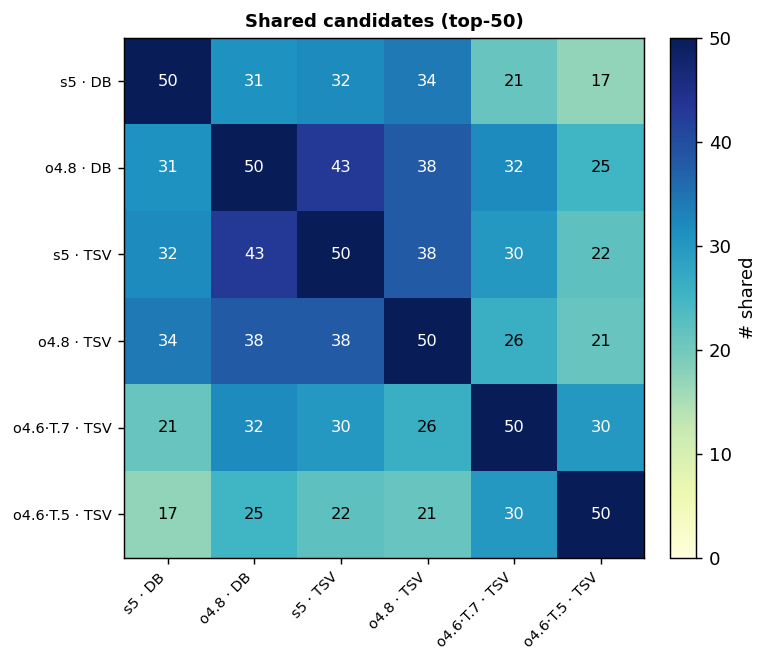

In [5]:
# ============================================================
# Heatmap of pairwise shared-candidate counts
# ============================================================
import matplotlib
matplotlib.rcParams['figure.dpi'] = 130
import matplotlib.pyplot as plt
import numpy as np

M = shared.astype(int).values
fig, ax = plt.subplots(figsize=(6.2, 5.2))
im = ax.imshow(M, cmap='YlGnBu', vmin=0, vmax=50)
ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels, fontsize=8)
for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, M[i, j], ha='center', va='center',
                color='white' if M[i, j] > 28 else 'black', fontsize=9)
ax.set_title('Shared candidates (top-50)', fontsize=10, fontweight='bold')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='# shared')
fig.tight_layout()
fig.savefig(COMPARISONS_DIR / 'overlap_heatmap.png', bbox_inches='tight')
print('saved', COMPARISONS_DIR / 'overlap_heatmap.png')
plt.show()


---
## Task 3 — Consensus top-N across all experiments

In [6]:
# ============================================================
# Rank-weighted consensus: score = (TOPN - rank + 1), summed across experiments
# ============================================================
from collections import defaultdict
TOPN_C = 20
score   = defaultdict(float)
sources = defaultdict(dict)   # locus -> {label: rank}
genes   = {}
for e in EXPERIMENTS:
    d = cand[e['label']].head(TOPN_C)
    for _, r in d.iterrows():
        lid = r['locus_id']
        score[lid]   += (TOPN_C - int(r['rank']) + 1)
        sources[lid][e['label']] = int(r['rank'])
        genes.setdefault(lid, r['gene'])

cons = (pd.DataFrame([
        {'LocusId': lid, 'Gene': genes.get(lid), 'ConsensusScore': score[lid],
         'N_exp': len(sources[lid]),
         'is_YES': lid in yes_keys, 'is_Possible': lid in possible_keys}
        for lid in score])
        .sort_values(['ConsensusScore','N_exp'], ascending=False)
        .reset_index(drop=True))
cons.insert(0, 'Rank', range(1, len(cons)+1))
consensus_df = cons
rank_matrix  = sources
consensus_df.head(20)


,Rank,LocusId,Gene,ConsensusScore,N_exp,is_YES,is_Possible
0,1,17-32142451-32142499-CCG,RHOT1,90.0,6,False,False
1,2,19-10871583-10871649-GCG,CARM1,81.0,5,False,False
2,3,5-443220-443277-GGC,EXOC3,77.0,4,False,False
3,4,X-149631735-149631780-CGC,TMEM185A,73.0,6,False,True
4,5,X-148500631-148500691-GCC,AFF2,59.0,4,True,False
5,6,X-19990922-19990973-CCG,BCLAF3,54.0,5,False,True
6,7,12-124567591-124567636-GGC,NCOR2,51.0,5,False,False
7,8,2-190880872-190880920-GCA,GLS,50.0,4,True,False
8,9,13-35476296-35476353-CTG,MAB21L1,48.0,4,False,False
9,10,2-111120967-111121021-GCC,BCL2L11,44.0,4,False,False


saved /blue/zhou/leizhou/Agents/George/analysis/comparisons/consensus_list.png


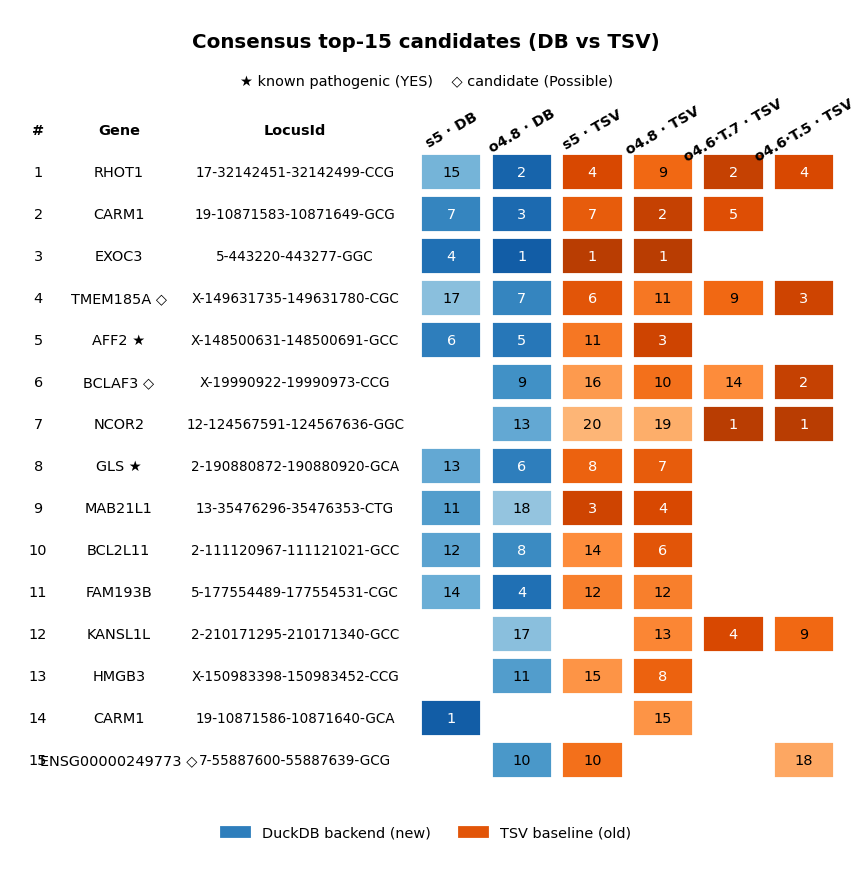

In [7]:
# ============================================================
# Figure: consensus top-N table with per-experiment rank blocks
# (columns colour-coded by backend: DB=blue family, TSV=orange family)
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.cm as cm

TOP = 15
top = consensus_df.head(TOP)
exps = [e['label'] for e in EXPERIMENTS]
back_cmap = {'DB': cm.Blues, 'TSV': cm.Oranges}
exp_back  = {e['label']: e['backend'] for e in EXPERIMENTS}

n_exp = len(exps)
ROW = 0.42
col_w = [0.5, 1.1, 2.4] + [0.7]*n_exp
xs = [0]; [xs.append(xs[-1]+w) for w in col_w[:-1]]
# height = title band + marker note + header + TOP rows + legend band
TITLE_BAND, HDR_BAND, LEG_BAND = 0.9, 0.55, 0.9
W = sum(col_w); H = TITLE_BAND + HDR_BAND + TOP*ROW + LEG_BAND
fig, ax = plt.subplots(figsize=(W, H)); ax.set_xlim(0, W); ax.set_ylim(0, H); ax.axis('off')
ax.text(W/2, H-0.2, 'Consensus top-%d candidates (DB vs TSV)' % TOP,
        ha='center', va='top', fontsize=11, fontweight='bold')
ax.text(W/2, H-0.62, '★ known pathogenic (YES)    ◇ candidate (Possible)',
        ha='center', va='top', fontsize=8)
hdr = ['#', 'Gene', 'LocusId'] + exps
y0 = H - TITLE_BAND - HDR_BAND/2
for i, h in enumerate(hdr):
    ax.text(xs[i]+col_w[i]/2, y0, h, ha='center', va='center', fontsize=8,
            fontweight='bold', rotation=0 if i < 3 else 30)
for ri, row in enumerate(top.itertuples()):
    y = y0 - ROW*(ri+1)
    star = ' ★' if row.is_YES else (' ◇' if row.is_Possible else '')
    ax.text(xs[0]+col_w[0]/2, y, str(row.Rank), ha='center', va='center', fontsize=8)
    ax.text(xs[1]+col_w[1]/2, y, str(row.Gene)+star, ha='center', va='center', fontsize=8)
    ax.text(xs[2]+col_w[2]/2, y, row.LocusId, ha='center', va='center', fontsize=7.5)
    for ei, exp in enumerate(exps):
        rnk = rank_matrix.get(row.LocusId, {}).get(exp)
        cx, cw = xs[3+ei], col_w[3+ei]
        if rnk is not None:
            shade = back_cmap[exp_back[exp]](0.35 + 0.5*(1 - rnk/20))
            ax.add_patch(plt.Rectangle((cx+0.05, y-0.18), cw-0.1, 0.36,
                         facecolor=shade, edgecolor='white'))
            ax.text(cx+cw/2, y, str(rnk), ha='center', va='center', fontsize=8,
                    color='white' if rnk <= 8 else 'black')
# legend — centered in the reserved bottom band, clear of the last row
import matplotlib.patches as mpatches
handles = [mpatches.Patch(color=cm.Blues(0.7), label='DuckDB backend (new)'),
           mpatches.Patch(color=cm.Oranges(0.7), label='TSV baseline (old)')]
ax.legend(handles=handles, loc='center', ncol=2, fontsize=8,
          bbox_to_anchor=(0.5, (LEG_BAND/2)/H), frameon=False)
fig.savefig(COMPARISONS_DIR / 'consensus_list.png', bbox_inches='tight')
print('saved', COMPARISONS_DIR / 'consensus_list.png')
plt.show()


In [8]:
# ============================================================
# Save tables + a short markdown report
# ============================================================
scored_out = scored_df.copy()
scored_out['YES_ranks'] = scored_out['YES_ranks'].astype(str)
scored_out['Possible_genes'] = scored_out['Possible_genes'].astype(str)
scored_out.to_csv(COMPARISONS_DIR / 'experiment_scores.csv', index=False)
shared.astype(int).to_csv(COMPARISONS_DIR / 'overlap_shared_counts.csv')
consensus_df.to_csv(COMPARISONS_DIR / 'consensus_top_candidates.csv', index=False)

from datetime import datetime
lines = [
    '# DB-vs-TSV Comparison Report', '',
    f'_Generated {datetime.now():%Y-%m-%d %H:%M}_  ·  {len(EXPERIMENTS)} experiments', '',
    '## Task 1 — key recovery', '', scored_out.drop(columns=['YES_ranks','Possible_genes']).to_markdown(index=False), '',
    '## Task 2 — shared candidates (top-50)', '', shared.astype(int).to_markdown(), '',
    '## Task 3 — consensus top-15', '', consensus_df.head(15).to_markdown(index=False), '',
]
(COMPARISONS_DIR / 'comparison_report.md').write_text('\n'.join(lines))
print('Saved to', COMPARISONS_DIR)
for f in sorted(COMPARISONS_DIR.iterdir()):
    print('  ', f.name)


Saved to /blue/zhou/leizhou/Agents/George/analysis/comparisons
   comparison_report.md
   consensus_list.png
   consensus_top_candidates.csv
   experiment_scores.csv
   overlap_heatmap.png
   overlap_shared_counts.csv
